## 📈 Predicting English Rugby Premiership Final Positions Using Probabilistic Modelling & Simulation

**Competition:** English Rugby Premiership 2025/26  
**Purpose:** Estimate probabilities of final league positions using simulation  
**Methods:** Monte Carlo simulation  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)   
**Medium Articles:**   
[Predicting English Rugby Premiership Final Positions Using Probabilistic Modelling & Simulation](https://medium.com/@vickyfrissdekereki/predicting-english-rugby-premiership-final-positions-using-probabilistic-modelling-simulation-353a7810be10)  
[How I Built a Rugby Dataset from Scratch with Web Scraping in Python](https://medium.com/@vickyfrissdekereki/how-i-built-a-rugby-dataset-from-scratch-with-web-scraping-in-python-9de4c6de95b2)  
[Predicting English Rugby Premiership Final Positions: A Technical Walkthrough in Python](https://medium.com/@vickyfrissdekereki/predicting-english-rugby-premiership-final-positions-a-technical-walkthrough-in-python-1d4a7a955375)

---

**Notebook first written:** `30/01/2026`  
**Last updated:** `23/04/2026`  

> This notebook develops a probabilistic framework to predict final English Rugby Premiership final positions using past matches breakdown to build probabilities of each outcome for each remaining match, which are then used to simulate the remainder of the season via Monte Carlo methods, generating distributions over final points totals and league positions.
>
> The analysis focuses on estimating the likelihood of key outcomes such as title wins, top-four finishes (qualification to play-offs), etc. Results are presented at team level with uncertainty intervals, and the framework can be extended to incorporate form, fixture difficulty, or alternative predictive inputs beyond betting markets.


<div style="text-align: left;">
    <img src="Images and others/Predicting English Rugby Premiership Final Positions Using Probabilistic Modelling & Simulation.png"  
         alt="Predicting English Rugby Premiership Final Positions Using Probabilistic Modelling & Simulation"  
         width="600">
</div>

In [1]:
# Core
from datetime import datetime, timedelta
import os

# Data manipulation
import numpy as np
import pandas as pd

# APIs & environment
import requests
from dotenv import load_dotenv

# Statistics
from scipy.stats import poisson

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

## 1. Premiership Final Standings (ESPN Scraping)
##### Adapting the ESPN scraper I built in my previous project to be used for Rugby Premiership instead of Football Premier League.

In [2]:
url = "https://www.espn.com/rugby/standings/_/league/267979"
tables = pd.read_html(url)

# Fix ESPN header issue
teams_raw = tables[0].copy()

# Move column names into first row
teams_raw.loc[-1] = teams_raw.columns
teams_raw.index = teams_raw.index + 1
teams_raw = teams_raw.sort_index().reset_index(drop=True)

# Stats table is fine as-is
stats = tables[1]

# Parse team table
teams = pd.DataFrame()

teams["position"] = (
    teams_raw.iloc[:, 0]
    .astype(str)
    .str.extract(r"^(\d+)")
    .astype(int)
)

teams["team"] = (
    teams_raw.iloc[:, 0]
    .astype(str)
    .str.replace(r"^\d+", "", regex=True)        # remove position
    .str.replace(r"^[A-Z]{2,3}", "", regex=True) # remove abbreviation
    .str.strip()
)

# Parse stats table
stats.columns = [
    "gp", "w", "d", "l", "bye",
    "pf", "pa", "tf", "ta",
    "tbp", "lbp", "bp",
    "pd", "pts"
]

stats = stats.apply(
    lambda c: (
        c.astype(str)
         .str.replace("+", "", regex=False)
         .astype(int)
    )
)

# Combine
premiership = pd.concat([teams, stats], axis=1)

premiership.to_csv('premiership.csv', index=False)

premiership

,position,team,gp,w,d,l,bye,pf,pa,tf,ta,tbp,lbp,bp,pd,pts
0,1,Northampton Saints,13,11,1,1,0,474,354,70,49,11,0,11,120,57
1,2,Bath Rugby,13,11,0,2,0,484,293,72,42,11,1,12,191,56
2,3,Leicester Tigers,13,10,0,3,0,432,277,61,37,10,1,11,155,51
3,4,Exeter Chiefs,13,8,1,4,0,364,242,51,33,9,4,13,122,47
4,5,Bristol Rugby,13,9,0,4,0,376,298,53,42,6,1,7,78,43
5,6,Saracens,13,6,0,7,0,500,350,73,50,10,4,14,150,38
6,7,Sale Sharks,13,3,0,10,0,344,439,48,65,6,4,10,-95,22
7,8,Gloucester Rugby,13,2,0,11,0,269,443,41,61,5,3,8,-174,16
8,9,Harlequins,13,3,0,10,0,248,439,33,66,2,1,3,-191,15
9,10,Newcastle Falcons,13,1,0,12,0,211,567,29,86,2,1,3,-356,7


## 2. Get betting odds using API

#### No matches betting odds available as there is still over a month to go until the next match.

## 3. Get fixtures for upcoming EPL games
#### No API available for Premiership Rugby, so performing web scraping from https://www.skysports.com/rugby-union/competitions/gallagher-prem/fixtures instead.

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.skysports.com/rugby-union/competitions/gallagher-prem/fixtures"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")

fixtures_container = soup.find("div", class_="fixres__body")

month = None
date = None

dates = []
months = []
home_teams = []
away_teams = []
times = []

for elem in fixtures_container.children:
    # Skip empty elements or strings
    if not hasattr(elem, "name"):
        continue

    # Month header
    if elem.name == "h3" and "fixres__header1" in elem.get("class", []):
        month = elem.get_text(strip=True)

    # Date header
    elif elem.name == "h4" and "fixres__header2" in elem.get("class", []):
        date = elem.get_text(strip=True)

    # Match item
    elif elem.name == "div" and "fixres__item" in elem.get("class", []):
        home = elem.select_one("span.matches__participant--side1 span.swap-text__target").get_text(strip=True)
        away = elem.select_one("span.matches__participant--side2 span.swap-text__target").get_text(strip=True)
        time = elem.select_one("span.matches__date").get_text(strip=True)

        months.append(month)
        dates.append(date)
        home_teams.append(home)
        away_teams.append(away)
        times.append(time)

# Build DataFrame
df_future_1 = pd.DataFrame({
    "month": months,
    "date": dates,
    "time": times,
    "home_team": home_teams,
    "away_team": away_teams
})

print(df_future_1.head())
print("Total fixtures scraped:", len(df_future_1))

        month                 date   time            home_team  \
0  April 2026    Friday 24th April  19:45  Newcastle Red Bulls   
1  April 2026  Saturday 25th April  15:00           Harlequins   
2  April 2026  Saturday 25th April  15:05             Saracens   
3  April 2026  Saturday 25th April  17:30          Northampton   
4  April 2026    Sunday 26th April  15:30           Gloucester   

          away_team  
0     Bristol Bears  
1       Sale Sharks  
2  Leicester Tigers  
3              Bath  
4            Exeter  
Total fixtures scraped: 28


In [4]:
# Remove fixtures with TBC in either team
df_future_1 = df_future_1[~df_future_1["home_team"].str.contains("TBC") & ~df_future_1["away_team"].str.contains("TBC")].reset_index(drop=True)
df_future = df_future_1.copy()
print("Total fixtures after removing TBC matches:", len(df_future))

Total fixtures after removing TBC matches: 25


In [5]:
df_future.to_csv('df_future.csv', index=False)
df_future

,month,date,time,home_team,away_team
0,April 2026,Friday 24th April,19:45,Newcastle Red Bulls,Bristol Bears
1,April 2026,Saturday 25th April,15:00,Harlequins,Sale Sharks
2,April 2026,Saturday 25th April,15:05,Saracens,Leicester Tigers
3,April 2026,Saturday 25th April,17:30,Northampton,Bath
4,April 2026,Sunday 26th April,15:30,Gloucester,Exeter
5,May 2026,Friday 8th May,19:45,Gloucester,Sale Sharks
6,May 2026,Saturday 9th May,15:05,Leicester Tigers,Northampton
7,May 2026,Saturday 9th May,17:30,Bristol Bears,Saracens
8,May 2026,Sunday 10th May,15:00,Newcastle Red Bulls,Harlequins
9,May 2026,Sunday 10th May,15:30,Exeter,Bath


## 4. Get this season (2025/26) and last 2 seasons (2024/25 & 2023/24) results
### Again, no API available here. Will do web scraping from https://www.tntsports.co.uk/rugby/premiership/calendar-results.shtml to get tries and full breakdown.

In [6]:
import re

def scrape_match_stats(url):
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to load {url}")
        return None
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    # Extract season from URL
    match = re.search(r'/premiership/(\d{4}-\d{4})/', url)
    season = match.group(1) if match else None
    
    # Team names
    team_tags = soup.select('a[data-testid="atom-participant-banner"] div.overflow-hidden')
    if len(team_tags) != 2:
        print(f"Couldn't find team names for {url}")
        return None
    
    home_team = team_tags[0].text.strip()
    away_team = team_tags[1].text.strip()
    
    # Team scores
    score_tags = soup.select('div[data-testid="team-match-header-score-atom-container"] div[data-testid="match-score-atom-score-content-box-score"]')
    if len(score_tags) == 2:
        home_score = int(score_tags[0].text.strip())
        away_score = int(score_tags[1].text.strip())
    else:
        home_score = away_score = None
    
    # Match date
    date_tag = soup.select_one('div[data-testid="molecule-match-header-top"] div.caption-2.text-neutral-05')
    if date_tag:
        date_text = date_tag.text.strip()
        match_date = date_text.split("/")[-1].strip() if "/" in date_text else None
    else:
        match_date = None
    
    # Stats rows
    stats_rows = soup.select('div[data-testid="molecule-team-action-row"]')
    stats_dict = {}
    
    for row in stats_rows:
        stat_name_tag = row.find('span')
        if not stat_name_tag:
            continue
        stat_name = stat_name_tag.text.strip()
        
        participants = row.select('div[data-testid="molecule-team-action-row-participant"]')
        if len(participants) != 2:
            continue
        
        home_val = int(participants[0].find('div', class_='caps-s6-fx').text.strip())
        away_val = int(participants[1].find('div', class_='caps-s6-fx').text.strip())
        
        stats_dict[stat_name] = [home_val, away_val]
    
    return {
        "season": season,
        "date": match_date,
        "home_team": home_team,
        "away_team": away_team,
        "home_score": home_score,
        "away_score": away_score,
        **stats_dict
    } 

##### Generate list of URLs

In [7]:
season_match_ranges = {
    "2023-2024": {"start": 1457678, "end": 1457767},  # 90
    "2024-2025": {"start": 1548080, "end": 1548169},  # 90
    "2025-2026": {"start": 1628800, "end": 1628859},  # 60
}


urls = []

for season, bounds in season_match_ranges.items():
    start = bounds["start"]
    end = bounds["end"]

    for match_number in range(start, end + 1):
        url = (
            f"https://www.tntsports.co.uk/rugby/premiership/"
            f"{season}/live-match_mtc{match_number}/live.shtml"
        )
        urls.append(url)

In [8]:
import time

all_matches_stats = []

total = len(urls)

for i, url in enumerate(urls, start=1):
    print(f"[{i}/{total}] Scraping: {url}")

    try:
        match = scrape_match_stats(url)

        if match:
            all_matches_stats.append(match)
            print(f"    ✅ Success: {match['home_team']} vs {match['away_team']}")
        else:
            print("    ⚠️  No data returned")

    except Exception as e:
        print(f"    ❌ Error scraping {url}: {e}")

    # polite delay to avoid hammering the site
    time.sleep(1)

print("\nFinished scraping.")
print(f"Total successful matches: {len(all_matches_stats)}")

[1/240] Scraping: https://www.tntsports.co.uk/rugby/premiership/2023-2024/live-match_mtc1457678/live.shtml
    ✅ Success: Bristol Bears vs Leicester Tigers
[2/240] Scraping: https://www.tntsports.co.uk/rugby/premiership/2023-2024/live-match_mtc1457679/live.shtml
    ✅ Success: Exeter Chiefs vs Saracens
[3/240] Scraping: https://www.tntsports.co.uk/rugby/premiership/2023-2024/live-match_mtc1457680/live.shtml
    ✅ Success: Bath Rugby vs Newcastle Red Bulls
[4/240] Scraping: https://www.tntsports.co.uk/rugby/premiership/2023-2024/live-match_mtc1457681/live.shtml
    ✅ Success: Gloucester Rugby vs Harlequins
[5/240] Scraping: https://www.tntsports.co.uk/rugby/premiership/2023-2024/live-match_mtc1457682/live.shtml
    ✅ Success: Sale Sharks vs Northampton Saints
[6/240] Scraping: https://www.tntsports.co.uk/rugby/premiership/2023-2024/live-match_mtc1457683/live.shtml
    ✅ Success: Newcastle Red Bulls vs Gloucester Rugby
[7/240] Scraping: https://www.tntsports.co.uk/rugby/premiership/2023-

In [9]:
# Convert list of dicts to DataFrame
df_matches = pd.DataFrame(all_matches_stats)

# Split stats lists into separate home/away columns
for stat in ['Tries', 'Conversions', 'Penalties', 'Drops']:
    df_matches[[f'{stat}_home', f'{stat}_away']] = pd.DataFrame(df_matches[stat].tolist(), index=df_matches.index)
    df_matches.drop(columns=[stat], inplace=True)

# Reorder columns
df_matches = df_matches[
    ['season', 'date', 'home_team', 'away_team', 
     'home_score', 'away_score',
     'Tries_home', 'Tries_away',
     'Conversions_home', 'Conversions_away',
     'Penalties_home', 'Penalties_away',
     'Drops_home', 'Drops_away']
]

# Save to CSV
df_matches.to_csv('rugby_matches_stats.csv', index=False)

df_matches['season'].value_counts().sort_index().head()

season
2023-2024    90
2024-2025    90
2025-2026    60
Name: count, dtype: int64

##### Some basic quality checks

In [10]:
df_matches['season'].value_counts().sort_index()

season
2023-2024    90
2024-2025    90
2025-2026    60
Name: count, dtype: int64

In [11]:
# Count home matches
home_counts = df_matches['home_team'].value_counts()

# Count away matches
away_counts = df_matches['away_team'].value_counts()

# Combine them
total_counts = home_counts.add(away_counts, fill_value=0).astype(int).sort_values(ascending=False)

print(total_counts)

Bath Rugby             48
Bristol Bears          48
Exeter Chiefs          48
Gloucester Rugby       48
Harlequins             48
Leicester Tigers       48
Newcastle Red Bulls    48
Northampton Saints     48
Sale Sharks            48
Saracens               48
Name: count, dtype: int32


## 5. Combine and calculate probabilities of TRIES, CONVERSIONS, PENALTIES, TRY BONUS POINT, & LOSING BONUS POINT

In [12]:
past_premierships = df_matches.copy()

In [13]:
# Add weights: more recent games = more weight
past_premierships["weight"] = np.linspace(1, 2, len(past_premierships))  # simple linear weighting

In [14]:
past_premierships.tail()

,season,date,home_team,away_team,home_score,away_score,Tries_home,Tries_away,Conversions_home,Conversions_away,Penalties_home,Penalties_away,Drops_home,Drops_away,weight
235,2025-2026,28.03.2026,Gloucester Rugby,Leicester Tigers,17,36,3,6,1,3,0,0,0,0,1.983264
236,2025-2026,28.03.2026,Bristol Bears,Harlequins,14,18,2,2,2,1,0,2,0,0,1.987448
237,2025-2026,27.03.2026,Newcastle Red Bulls,Exeter Chiefs,14,38,2,6,2,4,0,0,0,0,1.991632
238,2025-2026,29.03.2026,Sale Sharks,Bath Rugby,26,31,4,5,3,3,0,0,0,0,1.995816
239,2025-2026,28.03.2026,Saracens,Northampton Saints,17,21,2,3,2,3,1,0,0,0,2.000000


In [15]:
home_advantage_tries = past_premierships['Tries_home'].mean() - past_premierships['Tries_away'].mean()
print("Home advantage (average tries):", home_advantage_tries)

home_advantage_penalties = past_premierships['Penalties_home'].mean() - past_premierships['Penalties_away'].mean()
print("Home advantage (average penalties):", home_advantage_penalties)      
# NO HOME ADVANTAGE FOR PENALTIES. Value is small and even negative, will be ignored.

Home advantage (average tries): 1.0791666666666666
Home advantage (average penalties): -0.0625


In [17]:
# All teams
teams = pd.unique(past_premierships[["home_team", "away_team"]].values.ravel("K"))

# Initialize
team_stats = {}
attack_points = pd.Series(1.0, index=teams)
defense_points = pd.Series(1.0, index=teams)
attack_tries = pd.Series(1.0, index=teams)
defense_tries = pd.Series(1.0, index=teams)

# --- TEAM-LEVEL AGGREGATION ---
for team in teams:
    home_games = past_premierships[past_premierships["home_team"] == team]
    away_games = past_premierships[past_premierships["away_team"] == team]

    # Points scored/conceded
    points_scored = (home_games["home_score"]*home_games["weight"]).sum() + \
                    (away_games["away_score"]*away_games["weight"]).sum()
    points_conceded = (home_games["away_score"]*home_games["weight"]).sum() + \
                      (away_games["home_score"]*away_games["weight"]).sum()

    # Tries scored/conceded
    tries_scored = (home_games["Tries_home"]*home_games["weight"]).sum() + \
                   (away_games["Tries_away"]*away_games["weight"]).sum()
    tries_conceded = (home_games["Tries_away"]*home_games["weight"]).sum() + \
                     (away_games["Tries_home"]*away_games["weight"]).sum()

    # Weighted matches
    matches = home_games["weight"].sum() + away_games["weight"].sum()

    # Save per game stats
    team_stats[team] = {
        "points_scored_per_game": points_scored/matches,
        "points_conceded_per_game": points_conceded/matches,
        "tries_scored_per_game": tries_scored/matches,
        "tries_conceded_per_game": tries_conceded/matches
    }

# --- LEAGUE AVERAGES ---
total_tries  = past_premierships["Tries_home"].sum() + past_premierships["Tries_away"].sum()
total_games = len(past_premierships)

league_avg_tries  = total_tries / (2 * total_games)

# --- RELATIVE TRY STRENGTHS ---
for team in teams:
    attack_tries[team] = team_stats[team]["tries_scored_per_game"] / league_avg_tries
    defense_tries[team] = team_stats[team]["tries_conceded_per_game"] / league_avg_tries

# --- CONVERSION RATE (FIXED WARNING) ---
teams_conv = pd.concat([
    past_premierships[['home_team','Tries_home','Conversions_home','weight']].rename(
        columns={'home_team':'team','Tries_home':'tries','Conversions_home':'conversions'}
    ),
    past_premierships[['away_team','Tries_away','Conversions_away','weight']].rename(
        columns={'away_team':'team','Tries_away':'tries','Conversions_away':'conversions'}
    )
])

team_conversion = (
    (teams_conv['conversions'] * teams_conv['weight']).groupby(teams_conv['team']).sum() /
    (teams_conv['tries'] * teams_conv['weight']).groupby(teams_conv['team']).sum()
)

# --- PENALTIES & DROPS (NEW - THIS WAS MISSING) ---

# Offensive
team_penalty_drop = pd.concat([
    past_premierships[['home_team','Penalties_home','Drops_home','weight']].rename(
        columns={'home_team':'team','Penalties_home':'penalties','Drops_home':'drops'}
    ),
    past_premierships[['away_team','Penalties_away','Drops_away','weight']].rename(
        columns={'away_team':'team','Penalties_away':'penalties','Drops_away':'drops'}
    )
])

team_penalty_drop = team_penalty_drop.groupby('team').apply(
    lambda x: pd.Series({
        'penalties_per_game': (x['penalties'] * x['weight']).sum() / x['weight'].sum(),
        'drops_per_game': (x['drops'] * x['weight']).sum() / x['weight'].sum()
    })
)

# Defensive
team_penalty_drop_def = pd.concat([
    past_premierships[['home_team','Penalties_away','Drops_away','weight']].rename(
        columns={'home_team':'team','Penalties_away':'penalties_conceded','Drops_away':'drops_conceded'}
    ),
    past_premierships[['away_team','Penalties_home','Drops_home','weight']].rename(
        columns={'away_team':'team','Penalties_home':'penalties_conceded','Drops_home':'drops_conceded'}
    )
])

team_penalty_drop_def = team_penalty_drop_def.groupby('team').apply(
    lambda x: pd.Series({
        'penalties_conceded_per_game': (x['penalties_conceded'] * x['weight']).sum() / x['weight'].sum(),
        'drops_conceded_per_game': (x['drops_conceded'] * x['weight']).sum() / x['weight'].sum()
    })
)

# --- LEAGUE AVERAGES FOR PENALTIES & DROPS ---
total_penalties = past_premierships["Penalties_home"].sum() + past_premierships["Penalties_away"].sum()
league_avg_penalties  = total_penalties / (2 * total_games)

total_drops = past_premierships["Drops_home"].sum() + past_premierships["Drops_away"].sum()
league_avg_drops  = total_drops / (2 * total_games)

# --- RELATIVE METRICS ---
penalties_per_game_rel = team_penalty_drop['penalties_per_game'] / league_avg_penalties
drops_per_game_rel     = team_penalty_drop['drops_per_game'] / league_avg_drops

penalties_conceded_per_game_rel = team_penalty_drop_def['penalties_conceded_per_game'] / league_avg_penalties
drops_conceded_per_game_rel     = team_penalty_drop_def['drops_conceded_per_game'] / league_avg_drops

# --- FINAL DATASET ---
team_strengths = pd.DataFrame({
    "attack_tries": attack_tries,
    "defense_tries": defense_tries,
    "conversion_rate": team_conversion,
    "attack_penalties": penalties_per_game_rel,
    "attack_drops": drops_per_game_rel,
    "defense_penalties": penalties_conceded_per_game_rel,
    "defense_drops": drops_conceded_per_game_rel
})

team_strengths = team_strengths.sort_values("attack_tries", ascending=False)

team_strengths

C:\Users\vicky\AppData\Local\Temp\ipykernel_50024\3762028011.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_penalty_drop = team_penalty_drop.groupby('team').apply(
C:\Users\vicky\AppData\Local\Temp\ipykernel_50024\3762028011.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_penalty_drop_def = team_penalty_drop_def.groupby('team').apply(


,attack_tries,defense_tries,conversion_rate,attack_penalties,attack_drops,defense_penalties,defense_drops
Bath Rugby,1.283522,0.837894,0.742851,0.770146,0.557750,1.013769,2.409482
Bristol Bears,1.229124,1.005965,0.741411,0.854144,0.000000,1.164307,1.171186
Northampton Saints,1.164012,1.005417,0.758385,0.832037,1.202952,1.080380,0.531753
Saracens,1.133237,0.922095,0.662792,1.169369,2.107195,0.963150,0.726555
Gloucester Rugby,1.004013,1.143881,0.699644,0.598158,0.000000,0.978985,0.533985
Leicester Tigers,1.000991,0.831454,0.730134,1.439276,1.341462,1.084125,1.302444
Exeter Chiefs,0.966597,0.883205,0.734397,0.869700,0.000000,0.833783,2.438095
Sale Sharks,0.947749,0.925596,0.734715,1.277939,3.280572,1.065973,0.558237
Harlequins,0.876850,1.105127,0.755010,0.828335,0.533643,0.769417,0.000000
Newcastle Red Bulls,0.556002,1.502091,0.748051,0.869228,0.649265,0.555173,0.000000


## 6. Model each component with Poisson

In [18]:
# --- Team name mapping ---
team_name_map = {
    "Bath": "Bath Rugby",
    "Bath Rugby": "Bath Rugby",
    "Exeter": "Exeter Chiefs",
    "Exeter Chiefs": "Exeter Chiefs",
    "Northampton": "Northampton Saints",
    "Northampton Saints": "Northampton Saints",
    "Newcastle Red Bulls": "Newcastle Red Bulls",
    "Newcastle Falcons": "Newcastle Red Bulls", # for premiership table
    "Bristol Bears": "Bristol Bears",
    "Bristol Rugby": "Bristol Bears",
    "Saracens": "Saracens",
    "Leicester Tigers": "Leicester Tigers",
    "Sale Sharks": "Sale Sharks",
    "Gloucester": "Gloucester Rugby",
    "Gloucester Rugby": "Gloucester Rugby",
    "Harlequins": "Harlequins"
}

# --- Apply mapping to df_future ---
df_future['home_team'] = df_future['home_team'].map(team_name_map)
df_future['away_team'] = df_future['away_team'].map(team_name_map)

# --- Apply mapping to premiership table
premiership['team'] = premiership['team'].map(team_name_map)

In [19]:
import pandas as pd
from scipy.stats import poisson

# --- FULL JOINT OUTCOMES SIMULATION ---
def simulate_match_joint(home_team, away_team, team_strengths, sims=10000):
    """
    Simulate a match multiple times and return joint probabilities for
    all 20 mutually exclusive outcomes:
    - 16 for win combinations (winner's bonus × loser's bonus)
    - 4 for draws (draw with/without bonus combinations)
    """
    # Get team stats
    home = team_strengths.loc[home_team]
    away = team_strengths.loc[away_team]

    home_tries_exp = home['attack_tries'] * away['defense_tries'] * home_advantage_tries * league_avg_tries
    away_tries_exp = away['attack_tries'] * home['defense_tries'] * league_avg_tries

    home_pen_exp = home['attack_penalties'] * away['defense_penalties'] * league_avg_penalties
    away_pen_exp = away['attack_penalties'] * home['defense_penalties'] * league_avg_penalties

    home_drop_exp = home['attack_drops'] * away['defense_drops'] * league_avg_drops
    away_drop_exp = away['attack_drops'] * home['defense_drops'] * league_avg_drops
    
    exp = {
        'home_tries': home_tries_exp,
        'away_tries': away_tries_exp,
        'home_converted': home_tries_exp * home['conversion_rate'],
        'away_converted': away_tries_exp * away['conversion_rate'],
        'home_pen': home_pen_exp,
        'away_pen': away_pen_exp,
        'home_drop': home_drop_exp,
        'away_drop': away_drop_exp
    }

    # Initialize all 20 outcomes
    outcome_counts = {f'{h}_{a}': 0 for h in
                      ['win_no_bonus','win_bonus','lose_no_bonus','lose_try_bonus','lose_close_bonus','lose_bonus2','draw_no_bonus','draw_bonus']
                      for a in
                      ['win_no_bonus','win_bonus','lose_no_bonus','lose_try_bonus','lose_close_bonus','lose_bonus2','draw_no_bonus','draw_bonus']}
    
    # Keep only the 20 valid combinations
    valid_keys = [
        'win_no_bonus_lose_no_bonus','win_no_bonus_lose_try_bonus','win_no_bonus_lose_close_bonus','win_no_bonus_lose_bonus2',
        'win_bonus_lose_no_bonus','win_bonus_lose_try_bonus','win_bonus_lose_close_bonus','win_bonus_lose_bonus2',
        'lose_no_bonus_win_no_bonus','lose_no_bonus_win_bonus','lose_try_bonus_win_no_bonus','lose_try_bonus_win_bonus',
        'lose_close_bonus_win_no_bonus','lose_close_bonus_win_bonus','lose_bonus2_win_no_bonus','lose_bonus2_win_bonus',
        'draw_no_bonus_draw_no_bonus','draw_no_bonus_draw_bonus','draw_bonus_draw_no_bonus','draw_bonus_draw_bonus'
    ]
    outcome_counts = {k: 0 for k in valid_keys}

    # --- Run simulations ---
    for _ in range(sims):
        home_tries = poisson.rvs(exp['home_tries'])
        away_tries = poisson.rvs(exp['away_tries'])
        home_converted = min(home_tries, poisson.rvs(exp['home_converted']))
        away_converted = min(away_tries, poisson.rvs(exp['away_converted']))
        home_pen = poisson.rvs(exp['home_pen'])
        away_pen = poisson.rvs(exp['away_pen'])
        home_drop = poisson.rvs(exp['home_drop'])
        away_drop = poisson.rvs(exp['away_drop'])

        home_points = home_tries*5 + home_converted*2 + home_pen*3 + home_drop*3
        away_points = away_tries*5 + away_converted*2 + away_pen*3 + away_drop*3

        home_bonus_try = home_tries >= 4
        away_bonus_try = away_tries >= 4
        home_bonus_close = (away_points - home_points) <= 7 and home_points < away_points
        away_bonus_close = (home_points - away_points) <= 7 and away_points < home_points

        # Determine outcomes
        if home_points > away_points:
            home_outcome = 'win_bonus' if home_bonus_try else 'win_no_bonus'
            if away_bonus_try and away_bonus_close:
                away_outcome = 'lose_bonus2'
            elif away_bonus_try:
                away_outcome = 'lose_try_bonus'
            elif away_bonus_close:
                away_outcome = 'lose_close_bonus'
            else:
                away_outcome = 'lose_no_bonus'
        elif home_points < away_points:
            away_outcome = 'win_bonus' if away_bonus_try else 'win_no_bonus'
            if home_bonus_try and home_bonus_close:
                home_outcome = 'lose_bonus2'
            elif home_bonus_try:
                home_outcome = 'lose_try_bonus'
            elif home_bonus_close:
                home_outcome = 'lose_close_bonus'
            else:
                home_outcome = 'lose_no_bonus'
        else:  # draw
            home_outcome = 'draw_bonus' if home_bonus_try else 'draw_no_bonus'
            away_outcome = 'draw_bonus' if away_bonus_try else 'draw_no_bonus'

        outcome_counts[f'{home_outcome}_{away_outcome}'] += 1

    # Convert counts to probabilities
    return {k: v / sims for k, v in outcome_counts.items()}

In [20]:
simulate_match_joint("Bath Rugby", "Bristol Bears", team_strengths, sims=10000)

{'win_no_bonus_lose_no_bonus': 0.0252,
 'win_no_bonus_lose_try_bonus': 0.0,
 'win_no_bonus_lose_close_bonus': 0.0313,
 'win_no_bonus_lose_bonus2': 0.0041,
 'win_bonus_lose_no_bonus': 0.326,
 'win_bonus_lose_try_bonus': 0.1759,
 'win_bonus_lose_close_bonus': 0.0261,
 'win_bonus_lose_bonus2': 0.0959,
 'lose_no_bonus_win_no_bonus': 0.0137,
 'lose_no_bonus_win_bonus': 0.0967,
 'lose_try_bonus_win_no_bonus': 0.0001,
 'lose_try_bonus_win_bonus': 0.0626,
 'lose_close_bonus_win_no_bonus': 0.0254,
 'lose_close_bonus_win_bonus': 0.0214,
 'lose_bonus2_win_no_bonus': 0.0022,
 'lose_bonus2_win_bonus': 0.0686,
 'draw_no_bonus_draw_no_bonus': 0.0082,
 'draw_no_bonus_draw_bonus': 0.0016,
 'draw_bonus_draw_no_bonus': 0.0015,
 'draw_bonus_draw_bonus': 0.0135}

In [21]:
# List of all 20 joint outcome keys
joint_keys = [
    'win_no_bonus_lose_no_bonus','win_no_bonus_lose_try_bonus','win_no_bonus_lose_close_bonus','win_no_bonus_lose_bonus2',
    'win_bonus_lose_no_bonus','win_bonus_lose_try_bonus','win_bonus_lose_close_bonus','win_bonus_lose_bonus2',
    'lose_no_bonus_win_no_bonus','lose_no_bonus_win_bonus','lose_try_bonus_win_no_bonus','lose_try_bonus_win_bonus',
    'lose_close_bonus_win_no_bonus','lose_close_bonus_win_bonus','lose_bonus2_win_no_bonus','lose_bonus2_win_bonus',
    'draw_no_bonus_draw_no_bonus','draw_no_bonus_draw_bonus','draw_bonus_draw_no_bonus','draw_bonus_draw_bonus'
]

def predict_fixtures_joint(df_future, team_strengths, sims=5000):
    """
    Run simulate_match_joint for each future fixture, 
    returning a DataFrame where each of the 20 outcomes is a column.
    """
    results = []

    for _, row in df_future.iterrows():
        home = row['home_team']
        away = row['away_team']

        # Run joint simulation
        outcome_probs = simulate_match_joint(home, away, team_strengths, sims)

        # Make sure all keys are present
        row_data = row.to_dict()
        for k in joint_keys:
            row_data[k] = outcome_probs.get(k, 0.0)

        results.append(row_data)

    return pd.DataFrame(results)

In [22]:
np.random.seed(14)
df_predictions = predict_fixtures_joint(df_future, team_strengths, sims=10000)

In [23]:
df_predictions.head()

,month,date,time,home_team,away_team,win_no_bonus_lose_no_bonus,win_no_bonus_lose_try_bonus,win_no_bonus_lose_close_bonus,win_no_bonus_lose_bonus2,win_bonus_lose_no_bonus,...,lose_try_bonus_win_no_bonus,lose_try_bonus_win_bonus,lose_close_bonus_win_no_bonus,lose_close_bonus_win_bonus,lose_bonus2_win_no_bonus,lose_bonus2_win_bonus,draw_no_bonus_draw_no_bonus,draw_no_bonus_draw_bonus,draw_bonus_draw_no_bonus,draw_bonus_draw_bonus
0,April 2026,Friday 24th April,19:45,Newcastle Red Bulls,Bristol Bears,0.0053,0.0001,0.0122,0.0003,0.0110,...,0.0000,0.1351,0.0226,0.0131,0.0007,0.0255,0.0019,0.0005,0.0002,0.0020
1,April 2026,Saturday 25th April,15:00,Harlequins,Sale Sharks,0.0411,0.0004,0.0638,0.0051,0.1471,...,0.0001,0.0697,0.0766,0.0380,0.0064,0.0643,0.0168,0.0012,0.0016,0.0088
2,April 2026,Saturday 25th April,15:05,Saracens,Leicester Tigers,0.0577,0.0001,0.0680,0.0067,0.2354,...,0.0004,0.0553,0.0654,0.0308,0.0074,0.0603,0.0153,0.0026,0.0024,0.0099
3,April 2026,Saturday 25th April,17:30,Northampton Saints,Bath Rugby,0.0190,0.0001,0.0340,0.0035,0.1290,...,0.0001,0.1373,0.0361,0.0287,0.0035,0.0907,0.0107,0.0016,0.0014,0.0139
4,April 2026,Sunday 26th April,15:30,Gloucester Rugby,Exeter Chiefs,0.0270,0.0002,0.0479,0.0024,0.1503,...,0.0003,0.0991,0.0628,0.0280,0.0057,0.0744,0.0173,0.0018,0.0034,0.0118


## 7. Run simulations to build the Premiership table probabilities

In [24]:
def simulate_once_rugby(fixtures, table):
    table_sim = table.copy()
    points = dict(zip(table_sim["team"], table_sim["pts"]))

    # List of all 20 outcome columns in your fixtures DataFrame
    outcome_keys = [
    'win_no_bonus_lose_no_bonus','win_no_bonus_lose_try_bonus','win_no_bonus_lose_close_bonus','win_no_bonus_lose_bonus2',
    'win_bonus_lose_no_bonus','win_bonus_lose_try_bonus','win_bonus_lose_close_bonus','win_bonus_lose_bonus2',
    'lose_no_bonus_win_no_bonus','lose_no_bonus_win_bonus','lose_try_bonus_win_no_bonus','lose_try_bonus_win_bonus',
    'lose_close_bonus_win_no_bonus','lose_close_bonus_win_bonus','lose_bonus2_win_no_bonus','lose_bonus2_win_bonus',
    'draw_no_bonus_draw_no_bonus','draw_no_bonus_draw_bonus','draw_bonus_draw_no_bonus','draw_bonus_draw_bonus'
    ]


    # Mapping outcome columns to points (home points, away points)
    points_map = {
        # Home wins
        'win_no_bonus_lose_no_bonus': (4, 0),
        'win_no_bonus_lose_try_bonus': (4, 1),
        'win_no_bonus_lose_close_bonus': (4, 1),
        'win_no_bonus_lose_bonus2': (4, 2),
        'win_bonus_lose_no_bonus': (5, 0),
        'win_bonus_lose_try_bonus': (5, 1),
        'win_bonus_lose_close_bonus': (5, 1),
        'win_bonus_lose_bonus2': (5, 2),
    
        # Home loses
        'lose_no_bonus_win_no_bonus': (0, 4),
        'lose_no_bonus_win_bonus': (0, 5),
        'lose_try_bonus_win_no_bonus': (1, 4),
        'lose_try_bonus_win_bonus': (1, 5),
        'lose_close_bonus_win_no_bonus': (1, 4),
        'lose_close_bonus_win_bonus': (1, 5),
        'lose_bonus2_win_no_bonus': (2, 4),
        'lose_bonus2_win_bonus': (2, 5),
    
        # Draws
        'draw_no_bonus_draw_no_bonus': (2, 2),
        'draw_no_bonus_draw_bonus': (2, 3),
        'draw_bonus_draw_no_bonus': (3, 2),
        'draw_bonus_draw_bonus': (3, 3)
    }

    for _, row in fixtures.iterrows():
        home = row["home_team"]
        away = row["away_team"]
        probs = [row[k] for k in outcome_keys]
        outcome = np.random.choice(outcome_keys, p=probs)

        home_pts, away_pts = points_map[outcome]
        points[home] += home_pts
        points[away] += away_pts

    result_df = table_sim.copy()
    result_df["pts"] = result_df["team"].map(points)
    result_df = result_df.sort_values(["pts"], ascending=False)
    result_df["position"] = np.arange(1, len(result_df)+1)

    return result_df


# -------------------------------
# RUN MULTIPLE SIMULATIONS
# -------------------------------
def run_simulations_rugby(fixtures, table, n_sim=10000):
    """
    Run many simulations to get probability distribution of finishing positions.
    Returns a DataFrame: rows=positions, columns=teams, values=counts.
    """
    position_counts = {team: np.zeros(len(table)) for team in table["team"]}

    for _ in range(n_sim):
        final_table = simulate_once_rugby(fixtures, table)
        for _, row in final_table.iterrows():
            position_counts[row["team"]][row["position"]-1] += 1

    pos_df = pd.DataFrame(position_counts, index=np.arange(1, len(table)+1))
    pos_df.index.name = "position"
    return pos_df


In [25]:
np.random.seed(14)

n_sim=10000

# Run simulations
position_counts = run_simulations_rugby(df_predictions, premiership, n_sim=n_sim)

# Convert counts to probabilities
position_probs = position_counts / n_sim

In [26]:
position_probs.index.name = "TEAM"
position_distribution_t = position_probs.T

In [27]:
position_distribution_pct = position_distribution_t.div(
    position_distribution_t.sum(axis=1),
    axis=0
) * 100


In [28]:
position_distribution_pct

TEAM,1,2,3,4,5,6,7,8,9,10
Northampton Saints,36.73,48.61,12.11,2.17,0.38,0.00,0.00,0.00,0.00,0.00
Bath Rugby,59.90,33.36,5.63,0.95,0.16,0.00,0.00,0.00,0.00,0.00
Leicester Tigers,3.21,14.14,50.69,20.07,9.27,2.62,0.00,0.00,0.00,0.00
Exeter Chiefs,0.15,2.81,19.95,36.18,28.09,12.82,0.00,0.00,0.00,0.00
Bristol Bears,0.01,1.06,9.35,30.11,39.69,19.76,0.02,0.00,0.00,0.00
Saracens,0.00,0.02,2.27,10.52,22.41,64.56,0.22,0.00,0.00,0.00
Sale Sharks,0.00,0.00,0.00,0.00,0.00,0.24,88.63,8.69,2.44,0.00
Gloucester Rugby,0.00,0.00,0.00,0.00,0.00,0.00,7.45,57.58,34.91,0.06
Harlequins,0.00,0.00,0.00,0.00,0.00,0.00,3.68,33.69,62.29,0.34
Newcastle Red Bulls,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.36,99.60


## 8. Preview and present the results graphically

In [29]:
# Build label mapping: "position  team" (extra space for 1-9)
team_labels = (
    premiership[["team", "position"]]
    .set_index("team")["position"]
    .map(lambda pos: f"{pos}{'  ' if pos < 10 else ' '}")
)

# Join position and team name into one label
team_labels = (
    premiership[["team", "position"]]
    .assign(
        label=lambda df: df.apply(
            lambda r: f"{r['position']}{'&nbsp;&nbsp;&nbsp;&nbsp;' if r['position'] < 10 else '&nbsp;&nbsp;'}{r['team']}",
            axis=1
        )
    )
    .set_index("team")["label"]
)


# Apply labels to your table index
position_distribution_pct.index = position_distribution_pct.index.map(team_labels)

# Drop position column if present
position_distribution_pct = position_distribution_pct.drop(columns=["position"], errors="ignore")

# Remove index name
position_distribution_pct.index.name = None

In [30]:
# Copy to avoid modifying original
position_distribution_pct = position_distribution_pct.copy()

# Prepend points from premiership table to team names
position_distribution_pct.index = [
    f"{team} ({pts})" 
    for team, pts in zip(position_distribution_pct.index, premiership["pts"])
]

In [31]:
greens = plt.cm.Greens
green_cmap = LinearSegmentedColormap.from_list(
    "Greens_soft",
    greens(np.linspace(0.03, 0.65, 256))
)

vmax = 45

def zero_style(val):
    if val < 0.005:
        return "background-color: white !important;"
    return ""

# ---- transform ONLY for colouring ----
color_data = position_distribution_pct.copy()
color_data = (color_data / vmax).pow(0.65) * vmax

position_distribution_pct.style \
    .background_gradient(
        cmap=green_cmap,
        vmin=0,
        vmax=vmax,
        gmap=color_data,
        axis=None          
    ) \
    .applymap(zero_style) \
    .format("{:.2f}%") \
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#e6edf4"),
            ("color", "#333"),
            ("text-align", "center"),
            ("font-family", "Inter, Roboto, Arial, sans-serif"),
            ("font-size", "13px"),
            ("font-weight", "600")
        ]},

        {"selector": "th.col_heading", "props": [
            ("text-align", "center")
        ]},

        {"selector": "th.row_heading", "props": [
            ("text-align", "left"),
            ("font-size", "13px"),
            ("font-weight", "600"),
            ("white-space", "nowrap"),
            ("max-width", "250px"),
            ("overflow", "hidden"),
            ("text-overflow", "ellipsis")
        ]},

        {"selector": "tr:nth-child(odd) th.row_heading", "props": [
            ("background-color", "#fbfcfe")
        ]},
        {"selector": "tr:nth-child(even) th.row_heading", "props": [
            ("background-color", "#e6edf4")
        ]},

        {"selector": "td", "props": [
            ("text-align", "center"),
            ("font-family", "Inter, Roboto, Arial, sans-serif"),
            ("font-size", "12px"),
            ("font-weight", "500"),
            ("color", "#000")
        ]}
    ])


C:\Users\vicky\AppData\Local\Temp\ipykernel_50024\2993668776.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(zero_style) \


TEAM,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (57),36.73%,48.61%,12.11%,2.17%,0.38%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (56),59.90%,33.36%,5.63%,0.95%,0.16%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),3.21%,14.14%,50.69%,20.07%,9.27%,2.62%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.15%,2.81%,19.95%,36.18%,28.09%,12.82%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.01%,1.06%,9.35%,30.11%,39.69%,19.76%,0.02%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.02%,2.27%,10.52%,22.41%,64.56%,0.22%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.24%,88.63%,8.69%,2.44%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,7.45%,57.58%,34.91%,0.06%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.68%,33.69%,62.29%,0.34%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.04%,0.36%,99.60%


## 9. Scenario analysis

In [43]:
# -------------------------------
# SCENARIO ANALYSIS - FULL PIPELINE
# -------------------------------

# 1. APPLY RESULT TO TABLE
def apply_forced_result_to_table(table, home_team, away_team, outcome):
    table_updated = table.copy()
    points = dict(zip(table_updated["team"], table_updated["pts"]))

    points_map = {
        'win_no_bonus_lose_no_bonus': (4, 0),
        'win_no_bonus_lose_try_bonus': (4, 1),
        'win_no_bonus_lose_close_bonus': (4, 1),
        'win_no_bonus_lose_bonus2': (4, 2),
        'win_bonus_lose_no_bonus': (5, 0),
        'win_bonus_lose_try_bonus': (5, 1),
        'win_bonus_lose_close_bonus': (5, 1),
        'win_bonus_lose_bonus2': (5, 2),

        'lose_no_bonus_win_no_bonus': (0, 4),
        'lose_no_bonus_win_bonus': (0, 5),
        'lose_try_bonus_win_no_bonus': (1, 4),
        'lose_try_bonus_win_bonus': (1, 5),
        'lose_close_bonus_win_no_bonus': (1, 4),
        'lose_close_bonus_win_bonus': (1, 5),
        'lose_bonus2_win_no_bonus': (2, 4),
        'lose_bonus2_win_bonus': (2, 5),

        'draw_no_bonus_draw_no_bonus': (2, 2),
        'draw_no_bonus_draw_bonus': (2, 3),
        'draw_bonus_draw_no_bonus': (3, 2),
        'draw_bonus_draw_bonus': (3, 3)
    }

    home_pts, away_pts = points_map[outcome]

    points[home_team] += home_pts
    points[away_team] += away_pts

    table_updated["pts"] = table_updated["team"].map(points)

    table_updated = table_updated.sort_values("pts", ascending=False).reset_index(drop=True)
    table_updated["position"] = np.arange(1, len(table_updated)+1)

    return table_updated


# 2. REMOVE PLAYED MATCH
def remove_played_match(df_predictions, home_team, away_team):
    return df_predictions[
        ~((df_predictions["home_team"] == home_team) &
          (df_predictions["away_team"] == away_team))
    ].copy()


# 3. MAIN SCENARIO FUNCTION
def run_scenario_analysis(
    df_predictions,
    premiership,
    scenarios,
    home_team="Northampton Saints",
    away_team="Bath Rugby",
    n_sim=10000
):
    scenario_tables = {}

    for scenario in scenarios:

        # --- Apply result to table ---
        table_updated = apply_forced_result_to_table(
            premiership,
            home_team,
            away_team,
            scenario
        )

        # --- Remove played match ---
        df_remaining = remove_played_match(
            df_predictions,
            home_team,
            away_team
        )

        # --- Simulate remaining season ---
        counts = run_simulations_rugby(df_remaining, table_updated, n_sim=n_sim)

        # --- Convert to probabilities ---
        probs = counts / n_sim
        dist = probs.T * 100

        # --- Build labels with updated positions ---
        labels = (
            table_updated[["team", "position"]]
            .assign(
                label=lambda df: df.apply(
                    lambda r: f"{r['position']}{'    ' if r['position'] < 10 else '  '}{r['team']}",
                    axis=1
                )
            )
            .set_index("team")["label"]
        )

        # Ensure correct order first
        dist = dist.loc[table_updated["team"]]
        
        # Build labels safely
        dist.index = [
            f"{pos}{'    ' if pos < 10 else '  '}{team} ({pts})"
            for pos, team, pts in zip(
                table_updated["position"],
                table_updated["team"],
                table_updated["pts"]
            )
        ]

        dist.index.name = None

        # --- Style table ---
        scenario_tables[scenario] = style_table(dist)

    return scenario_tables

In [44]:
scenarios = list({
    'win_no_bonus_lose_no_bonus': None,
    'win_no_bonus_lose_try_bonus': None,
    'win_no_bonus_lose_close_bonus': None,
    'win_no_bonus_lose_bonus2': None,
    'win_bonus_lose_no_bonus': None,
    'win_bonus_lose_try_bonus': None,
    'win_bonus_lose_close_bonus': None,
    'win_bonus_lose_bonus2': None,

    'lose_no_bonus_win_no_bonus': None,
    'lose_no_bonus_win_bonus': None,
    'lose_try_bonus_win_no_bonus': None,
    'lose_try_bonus_win_bonus': None,
    'lose_close_bonus_win_no_bonus': None,
    'lose_close_bonus_win_bonus': None,
    'lose_bonus2_win_no_bonus': None,
    'lose_bonus2_win_bonus': None,

    'draw_no_bonus_draw_no_bonus': None,
    'draw_no_bonus_draw_bonus': None,
    'draw_bonus_draw_no_bonus': None,
    'draw_bonus_draw_bonus': None
}.keys())

In [45]:
scenario_tables = run_scenario_analysis(
    df_predictions,
    premiership,
    scenarios,
    home_team="Northampton Saints",
    away_team="Bath Rugby",
    n_sim=10000
)

C:\Users\vicky\AppData\Local\Temp\ipykernel_50024\2283097051.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(zero_style) \
C:\Users\vicky\AppData\Local\Temp\ipykernel_50024\2283097051.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(zero_style) \
C:\Users\vicky\AppData\Local\Temp\ipykernel_50024\2283097051.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(zero_style) \
C:\Users\vicky\AppData\Local\Temp\ipykernel_50024\2283097051.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(zero_style) \
C:\Users\vicky\AppData\Local\Temp\ipykernel_50024\2283097051.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(zero_style) \
C:\Users\vicky\AppData\Local\Temp\ipykernel_50024\2283097051.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .app

In [53]:
from IPython.display import display, HTML

# -------------------------------
# FULL, CLEAR SCENARIO LABELS
# -------------------------------

scenario_names = {
    # --- Northampton wins ---
    "win_no_bonus_lose_no_bonus": "Northampton win | No bonus points",
    "win_no_bonus_lose_try_bonus": "Northampton win | Bath: Try bonus point",
    "win_no_bonus_lose_close_bonus": "Northampton win | Bath: Losing bonus point",
    "win_no_bonus_lose_bonus2": "Northampton win | Bath: 2 bonus points",

    "win_bonus_lose_no_bonus": "Northampton win | Northampton: Try bonus point",
    "win_bonus_lose_try_bonus": "Northampton win | Both teams: Try bonus point",
    "win_bonus_lose_close_bonus": "Northampton win | Northampton: Try BP, Bath: Losing BP",
    "win_bonus_lose_bonus2": "Northampton win | Northampton: Try BP, Bath: 2 BP",

    # --- Bath wins ---
    "lose_no_bonus_win_no_bonus": "Bath win | No bonus points",
    "lose_no_bonus_win_bonus": "Bath win | Bath: Try bonus point",

    "lose_try_bonus_win_no_bonus": "Bath win | Northampton: Try bonus point",
    "lose_try_bonus_win_bonus": "Bath win | Both teams: Try bonus point",

    "lose_close_bonus_win_no_bonus": "Bath win | Northampton: Losing bonus point",
    "lose_close_bonus_win_bonus": "Bath win | Bath: Try BP, Northampton: Losing BP",

    "lose_bonus2_win_no_bonus": "Bath win | Northampton: 2 bonus points",
    "lose_bonus2_win_bonus": "Bath win | Bath: Try BP, Northampton: 2 BP",

    # --- Draws ---
    "draw_no_bonus_draw_no_bonus": "Draw | No bonus points",
    "draw_no_bonus_draw_bonus": "Draw | Bath: Try bonus point",
    "draw_bonus_draw_no_bonus": "Draw | Northampton: Try bonus point",
    "draw_bonus_draw_bonus": "Draw | Both teams: Try bonus point"
}


# -------------------------------
# DISPLAY (TABLE-CENTERED + CLEAN HEADERS)
# -------------------------------

from IPython.display import display, HTML

# -------------------------------
# DISPLAY PERFECTLY CENTERED BLOCKS
# -------------------------------

for scenario, table in scenario_tables.items():
    
    label = scenario_names.get(scenario, scenario)

    # Render table as HTML string
    table_html = table.to_html()

    display(HTML(f"""
        <div style="
            width: 100%;
            display: flex;
            justify-content: center;
            margin-top: 30px;
            margin-bottom: 30px;
        ">
            <div style="
                display: inline-block;
                text-align: center;
            ">
                <div style="
                    font-size: 20px;
                    font-weight: 700;
                    margin-bottom: 12px;
                    font-family: Inter, Roboto, Arial, sans-serif;
                ">
                    {label}
                </div>

                {table_html}
            </div>
        </div>
    """))

position,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (61),69.95%,24.86%,4.62%,0.55%,0.02%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (56),25.43%,58.09%,13.44%,2.56%,0.48%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),4.13%,12.87%,49.89%,21.45%,9.29%,2.37%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.40%,3.14%,20.12%,35.11%,28.34%,12.89%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.09%,1.04%,9.76%,29.19%,39.21%,20.68%,0.03%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.00%,2.17%,11.14%,22.66%,63.72%,0.31%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.33%,89.02%,8.80%,1.85%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,6.75%,57.23%,35.97%,0.05%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,3.89%,33.93%,61.86%,0.31%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.04%,0.32%,99.64%


position,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (61),61.94%,31.98%,5.35%,0.72%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (57),33.91%,53.47%,10.70%,1.61%,0.31%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),3.83%,11.65%,53.48%,19.92%,8.87%,2.25%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.29%,2.17%,19.24%,37.21%,28.99%,12.10%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.03%,0.73%,8.81%,29.52%,39.97%,20.94%,0.00%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.00%,2.42%,11.02%,21.85%,64.41%,0.30%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.30%,88.40%,9.03%,2.27%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,7.19%,57.24%,35.48%,0.09%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,4.11%,33.73%,61.96%,0.20%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.29%,99.71%


position,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (61),62.30%,31.53%,5.39%,0.75%,0.03%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (57),33.19%,53.88%,10.98%,1.64%,0.31%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),4.24%,11.37%,52.19%,20.51%,9.47%,2.22%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.24%,2.47%,20.23%,36.80%,27.70%,12.56%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.03%,0.75%,9.08%,29.25%,40.35%,20.54%,0.00%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.00%,2.13%,11.05%,22.14%,64.37%,0.31%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.31%,89.07%,8.37%,2.25%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,6.75%,57.37%,35.78%,0.10%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.87%,34.25%,61.59%,0.29%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,0.38%,99.61%


position,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (61),56.29%,37.35%,5.68%,0.59%,0.09%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (58),40.22%,50.10%,8.44%,1.14%,0.10%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),3.29%,9.84%,54.31%,20.38%,9.95%,2.23%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.17%,2.09%,20.19%,37.22%,27.82%,12.51%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.03%,0.62%,9.16%,29.94%,40.30%,19.94%,0.01%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.00%,2.22%,10.73%,21.74%,65.10%,0.21%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.22%,89.17%,8.69%,1.92%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,6.64%,58.02%,35.30%,0.04%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.97%,33.28%,62.47%,0.28%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,0.31%,99.68%


position,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (62),75.63%,20.76%,3.28%,0.32%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (56),20.55%,61.91%,14.34%,2.68%,0.52%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),3.49%,13.18%,51.05%,20.75%,9.27%,2.26%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.29%,3.12%,19.66%,35.29%,28.27%,13.37%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.04%,1.02%,9.20%,29.96%,40.23%,19.55%,0.00%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.01%,2.47%,11.00%,21.70%,64.57%,0.25%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.25%,88.77%,8.89%,2.09%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,7.14%,56.80%,35.99%,0.07%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.84%,34.29%,61.63%,0.24%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.02%,0.29%,99.69%


...

position,1,2,3,4,5,6,7,8,9,10
1 Bath Rugby (61),78.66%,19.30%,1.93%,0.11%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Northampton Saints (59),18.76%,65.89%,13.35%,1.71%,0.29%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),2.51%,11.66%,52.61%,20.81%,9.95%,2.46%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.07%,2.22%,20.24%,36.45%,28.37%,12.65%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.00%,0.91%,9.29%,30.33%,39.13%,20.34%,0.00%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.02%,2.58%,10.59%,22.26%,64.38%,0.17%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.17%,89.60%,8.60%,1.63%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,6.56%,57.13%,36.28%,0.03%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.67%,34.26%,61.90%,0.17%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,0.19%,99.80%


position,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (59),42.34%,44.66%,10.89%,1.83%,0.28%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (58),52.26%,38.98%,7.47%,1.19%,0.10%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),4.84%,12.60%,49.75%,21.30%,9.21%,2.30%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.50%,2.71%,19.74%,35.23%,29.18%,12.64%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.06%,1.03%,9.62%,29.75%,39.09%,20.44%,0.01%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.02%,2.53%,10.70%,22.14%,64.32%,0.29%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.30%,89.18%,8.33%,2.19%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,6.97%,58.11%,34.87%,0.05%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.55%,33.56%,62.66%,0.23%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.28%,99.72%


position,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (59),36.15%,50.55%,11.31%,1.71%,0.28%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (59),59.54%,34.12%,5.55%,0.70%,0.09%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),3.99%,11.96%,51.98%,20.21%,9.67%,2.19%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.27%,2.41%,19.92%,36.44%,28.66%,12.30%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.05%,0.94%,8.92%,30.68%,39.81%,19.59%,0.01%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.02%,2.32%,10.26%,21.49%,65.65%,0.26%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.27%,89.46%,8.28%,1.99%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,6.87%,58.11%,34.99%,0.03%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.40%,33.59%,62.74%,0.27%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.02%,0.28%,99.70%


position,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (60),48.16%,42.57%,8.04%,1.14%,0.09%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (58),47.22%,43.53%,8.12%,1.00%,0.13%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),4.29%,11.19%,52.00%,20.64%,9.50%,2.38%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.28%,1.97%,19.74%,37.55%,28.25%,12.21%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.05%,0.74%,9.56%,29.63%,39.67%,20.35%,0.00%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.00%,2.54%,10.04%,22.36%,64.80%,0.25%,0.01%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.25%,89.68%,8.09%,1.98%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,6.74%,57.88%,35.31%,0.06%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.33%,34.02%,62.38%,0.27%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.33%,99.67%


position,1,2,3,4,5,6,7,8,9,10
1 Northampton Saints (60),43.20%,47.37%,8.08%,1.22%,0.13%,0.00%,0.00%,0.00%,0.00%,0.00%
2 Bath Rugby (59),52.70%,40.35%,6.22%,0.70%,0.03%,0.00%,0.00%,0.00%,0.00%,0.00%
3 Leicester Tigers (51),3.80%,9.75%,53.54%,21.24%,9.12%,2.55%,0.00%,0.00%,0.00%,0.00%
4 Exeter Chiefs (47),0.29%,1.88%,20.23%,35.97%,29.47%,12.16%,0.00%,0.00%,0.00%,0.00%
5 Bristol Bears (43),0.01%,0.65%,9.54%,30.31%,39.15%,20.30%,0.04%,0.00%,0.00%,0.00%
6 Saracens (38),0.00%,0.00%,2.39%,10.56%,22.10%,64.62%,0.33%,0.00%,0.00%,0.00%
7 Sale Sharks (22),0.00%,0.00%,0.00%,0.00%,0.00%,0.36%,89.05%,8.61%,1.98%,0.00%
8 Gloucester Rugby (16),0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,7.14%,57.95%,34.82%,0.08%
9 Harlequins (15),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.44%,33.43%,63.00%,0.13%
10 Newcastle Red Bulls (7),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,0.20%,99.79%


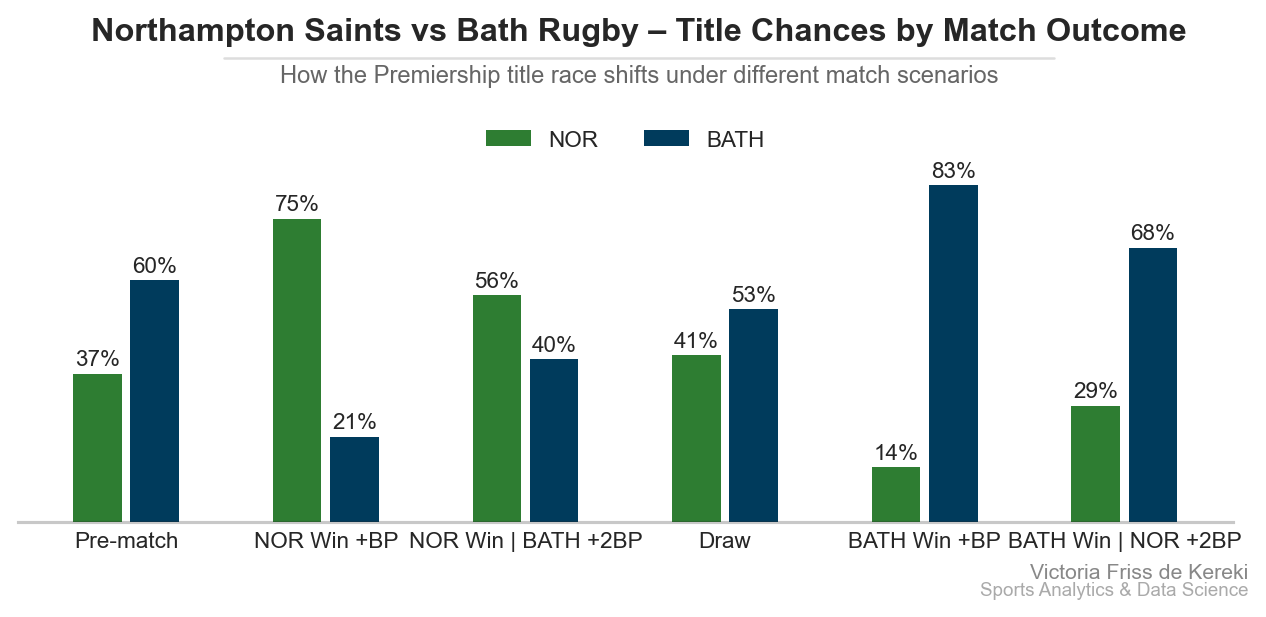

In [71]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ----------------------------
# SCENARIOS (clean + short)
# ----------------------------
scenarios = [
    "Pre-match",
    "NOR Win +BP",
    "NOR Win | BATH +2BP",
    "Draw",
    "BATH Win +BP",
    "BATH Win | NOR +2BP"
]

x = np.arange(len(scenarios)) * 1.15
width = 0.28
gap = 0.05

# ----------------------------
# STYLE
# ----------------------------
plt.style.use("seaborn-v0_8-white")

fig, ax = plt.subplots(figsize=(7.2, 3.3), dpi=180)

fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

# ----------------------------
# TEAM COLOURS (your choice)
# ----------------------------
home_color = "#2E7D32"   # Northampton
away_color = "#003B5C"   # Bath

# ----------------------------
# BARS
# ----------------------------
bars_home = ax.bar(x - (width/2 + gap/2), home_probs, width, color=home_color)
bars_away = ax.bar(x + (width/2 + gap/2), away_probs, width, color=away_color)

# ----------------------------
# HEADER
# ----------------------------
fig.text(
    0.5, 0.965,
    "Northampton Saints vs Bath Rugby – Title Chances by Match Outcome",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

fig.lines.append(plt.Line2D(
    [0.18, 0.82], [0.935, 0.935],
    transform=fig.transFigure,
    color="#dddddd",
    linewidth=1
))

fig.text(
    0.5, 0.895,   # slightly higher → tighter layout
    "How the Premiership title race shifts under different match scenarios",
    ha="center",
    fontsize=9.5,
    color="#666666"
)

# ----------------------------
# AXES
# ----------------------------
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=9)
ax.tick_params(axis='x', length=0)

ax.set_ylim(0, 100)
ax.set_yticks([])

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_alpha(0.25)

# ----------------------------
# VALUE LABELS (NO DECIMALS)
# ----------------------------
for bar in list(bars_home) + list(bars_away):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,
        f"{int(round(h))}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ----------------------------
# LEGEND (fixed spacing)
# ----------------------------
legend_elements = [
    Patch(facecolor=home_color, label="NOR"),
    Patch(facecolor=away_color, label="BATH")
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),   # pulled closer to plot
    ncol=2,
    fontsize=9
)

# ----------------------------
# FOOTER
# ----------------------------
fig.text(
    0.97, 0.06,
    "Victoria Friss de Kereki",
    ha="right",
    fontsize=8.5,
    color="#888888"
)

fig.text(
    0.97, 0.031,
    "Sports Analytics & Data Science",
    ha="right",
    fontsize=7.5,
    color="#aaaaaa"
)

# ----------------------------
# LAYOUT (more vertical space)
# ----------------------------
plt.tight_layout(rect=[0, 0.06, 1, 0.88])

plt.show()